## Measure Day 

**Date: 05/10/2026**  
**Time: 13.45 - 17.45**  

**Research question:**  How does the initial gravitational potential energy $E_0$ of a double pendulum affect the finite-time exponential divergence rate $\lambda$  of nearby trajectories?  
**Assumptions:** The initial kinetic energy of the double pendulum is neglected, because the pendulum is released from rest.  
**Hypothesis**:  At lower initial gravitational potential energy, the double pendulum remains close to the small-angle regime where its equations of motion are lineair and the motion approximately harmonic. As this initial energy increases, the small angle approximation becomes invalid and nonlineair effects become more important. We therefore expect finite time exponential divergence rate to increase with initial gravitational potential energy.  
**Measuring Setup:**  
**Measuring Plan:**  
- Measure the pendulums lengths L1 and L2
- measure the pendulum masses m1 and m2
- mark the center of masses with distinguishable red and green markers. 
- place the camera parallel to the plane of motion
- fix the camera for the entire experiment and note its settings
- test that the motion of the pendulum stays inside the video frame  

Repeat the following measurements for initial angles of $\theta_1$ = 10 $^{\circ}$, 20 $^{\circ}$  ,30 $^{\circ}$  ,40 $^{\circ}$  ,50 $^{\circ}$  ,60 $^{\circ}$    and $\theta_2$ = 0 $^{\circ}$

- place the pendulum in the first initial position
- let the pendulum come to rest
- start recording while still holding the pendulum without blocking the markers
- record the release from rest out of this initial condition
- stop the recording. Later, extract the actual initial angles from the first video frames
- place the pendulum in the same initial condition with an increase of $\theta_1$ equal to 3 degrees
- record the release from rest again
- import these files into python
- run the tracking code and check that the markers have been tracked correctly
- repeat all steps with an increase in initial angles  
- *make repeated measurements for each initial state*  
 **Data Analysis Procedure**: 

# Dubbele slinger — van pixels naar $(r,\phi)$, impulsen en $\lambda_{FT}$

Dit notebook bouwt voort op `Pendulum tracking.ipynb` en volgt het stappenplan:

1. **Parameters & kalibratie** (L1, L2, m1, m2, pixels/m, pivotpositie)
2. **Tracking van beide markers** → CSV met `x1, y1, x2, y2` in pixels
3. **Pixels → $(r_i, \phi_i)$** met de formules uit de theorie (§10)
4. **Hoeksnelheden, impulsen $p_1, p_2$, energie** → canonieke CSV per opname
5. **$U_0$** van een loslating vanuit stilstand
6. **Twee opnames vergelijken**: $\delta(\tau)$, $\ln[\delta/\delta_0]$, lineaire fit → $\lambda_{FT}$
7. **$\lambda_{FT}$ vs $U_0$**

Onderaan staat een **test met gesimuleerde data**, zodat je de hele pijplijn kunt controleren zonder video's (en kunt zien wat je theoretisch mag verwachten).

**Coördinaten:** oorsprong in het ophangpunt, $y$ omhoog (beeld-$y$ wijst omlaag, dus die wordt omgeklapt).
$\phi_i$ is de hoek van staaf $i$ t.o.v. de neerwaartse verticaal, positief richting $+x$. $r_i$ is de lengte van staaf $i$ zoals gemeten in het beeld — die hoort constant te zijn ($\approx L_i$) en is dus een goede kwaliteitscontrole op kalibratie en tracking.

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
from scipy.integrate import solve_ivp

## 1. Parameters en kalibratie
Vul hier jullie gemeten waarden in (met onzekerheid in je logboek). De pivotpositie en `px_per_m` haal je uit de first-frame PNG (bijv. in Paint/ImageJ de pixelcoördinaten van de pivot en van twee punten op de liniaal aflezen).

In [2]:
g = 9.81          # m/s^2

# --- GEMETEN WAARDEN (aanpassen!) ---
L1 = 0.200        # m, effectieve lengte arm 1 (pivot -> marker 1)
L2 = 0.200        # m, effectieve lengte arm 2 (marker 1 -> marker 2)
m1 = 0.100        # kg
m2 = 0.100        # kg

# Kalibratie uit first frame
ruler_p1 = (500, 900)     # pixelcoördinaten van een punt op de liniaal
ruler_p2 = (1300, 900)    # pixelcoördinaten van een tweede punt
ruler_dist_m = 0.40       # werkelijke afstand tussen die twee punten in m
px_per_m = np.hypot(ruler_p2[0]-ruler_p1[0], ruler_p2[1]-ruler_p1[1]) / ruler_dist_m

pivot_px = (960, 300)     # (X0, Y0) in pixels

print(f"px_per_m = {px_per_m:.1f}  (= {px_per_m/100:.2f} px/cm)")
print(f"L1 in pixels ≈ {L1*px_per_m:.0f}, L2 in pixels ≈ {L2*px_per_m:.0f}")

px_per_m = 2000.0  (= 20.00 px/cm)
L1 in pixels ≈ 400, L2 in pixels ≈ 400


## 2. Tracking van **beide** markers
De bestaande `detect_red_point` pakt alleen de grootste rode blob. Voor de hoeken heb je beide scharnierpunten nodig. Hier pakken we de twee grootste rode blobs en bepalen we welke welke is:

- marker 1 zit altijd op afstand $\approx L_1$ van de pivot, marker 2 kan overal tussen $0$ en $L_1+L_2$ zitten;
- daarnaast gebruiken we continuïteit met het vorige frame (markers springen niet ver tussen frames).

Als de markers verschillende kleuren hebben (bijv. rood en blauw) is dat robuuster — dan kun je `detect_color_blobs` gewoon twee keer met andere HSV-grenzen aanroepen.

In [3]:
RED_RANGES = [((0, 80, 50), (10, 255, 255)), ((170, 80, 50), (180, 255, 255))]

def detect_color_blobs(frame, hsv_ranges=RED_RANGES, n=2, min_area=10):
    # Geeft een lijst van max n centroids (x, y) in pixels, grootste blobs eerst, plus het masker.
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    mask = np.zeros(hsv.shape[:2], np.uint8)
    for lo, hi in hsv_ranges:
        mask |= cv2.inRange(hsv, np.array(lo), np.array(hi))
    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    pts = []
    for c in contours[:n]:
        if cv2.contourArea(c) < min_area:
            continue
        M = cv2.moments(c)
        if M["m00"] > 0:
            pts.append((M["m10"] / M["m00"], M["m01"] / M["m00"]))   # sub-pixel centroid
    return pts, mask


def assign_markers(pts, pivot_px, L1_px, prev=None):
    # Bepaal welke blob marker 1 (bovenste scharnier) en marker 2 (onderste massa) is.
    # Return (p1, p2); een ontbrekende marker wordt None.
    X0, Y0 = pivot_px
    if len(pts) == 0:
        return None, None
    if len(pts) == 1:
        p = pts[0]
        # Eén blob: kijk welke vorige positie het dichtst bij ligt
        if prev is not None and prev[0] is not None and prev[1] is not None:
            d1 = np.hypot(p[0]-prev[0][0], p[1]-prev[0][1])
            d2 = np.hypot(p[0]-prev[1][0], p[1]-prev[1][1])
            return (p, None) if d1 < d2 else (None, p)
        return None, None
    a, b = pts[0], pts[1]
    # kosten van toewijzing (a=1, b=2) vs (b=1, a=2)
    def cost(q1, q2):
        c = abs(np.hypot(q1[0]-X0, q1[1]-Y0) - L1_px)          # marker 1 ligt op cirkel met straal L1
        if prev is not None and prev[0] is not None and prev[1] is not None:
            c += 0.5 * (np.hypot(q1[0]-prev[0][0], q1[1]-prev[0][1])
                        + np.hypot(q2[0]-prev[1][0], q2[1]-prev[1][1]))
        return c
    return (a, b) if cost(a, b) <= cost(b, a) else (b, a)


def process_video_two_markers(video_path, output_csv, pivot_px, L1_px,
                              hsv_ranges=RED_RANGES, preview=False, save_annotated=False):
    video_path = Path(video_path)
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Could not open video: {video_path}")
    fps = cap.get(cv2.CAP_PROP_FPS)
    w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    writer = None
    if save_annotated:
        out = video_path.with_name(video_path.stem + "_tracked2.mp4")
        writer = cv2.VideoWriter(str(out), cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

    rows, prev, i = [], None, 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        pts, mask = detect_color_blobs(frame, hsv_ranges, n=2)
        p1, p2 = assign_markers(pts, pivot_px, L1_px, prev)
        prev = (p1 if p1 is not None else (prev[0] if prev else None),
                p2 if p2 is not None else (prev[1] if prev else None))
        rows.append({"frame": i, "time_s": i / fps,
                     "x1": p1[0] if p1 else np.nan, "y1": p1[1] if p1 else np.nan,
                     "x2": p2[0] if p2 else np.nan, "y2": p2[1] if p2 else np.nan})
        if writer is not None or preview:
            ann = frame.copy()
            cv2.circle(ann, tuple(int(v) for v in pivot_px), 6, (255, 255, 0), -1)
            last = tuple(int(v) for v in pivot_px)
            for p, col, lab in [(p1, (0, 255, 0), "1"), (p2, (255, 0, 255), "2")]:
                if p is not None:
                    q = (int(p[0]), int(p[1]))
                    cv2.line(ann, last, q, (255, 255, 255), 2); last = q
                    cv2.circle(ann, q, 7, col, -1)
                    cv2.putText(ann, lab, (q[0]+10, q[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, col, 2)
            if writer is not None:
                writer.write(ann)
            if preview:
                cv2.imshow("tracking (q = stop)", cv2.resize(ann, None, fx=0.5, fy=0.5))
                if cv2.waitKey(1) & 0xFF == ord("q"):
                    break
        i += 1
    cap.release()
    if writer is not None:
        writer.release()
    cv2.destroyAllWindows()
    df = pd.DataFrame(rows)
    df.to_csv(output_csv, index=False)
    print(f"Saved {output_csv}: {len(df)} frames, fps = {fps:.2f}")
    print("Missende detecties: marker1 =", df.x1.isna().sum(), ", marker2 =", df.x2.isna().sum())
    return df

In [4]:
# Voorbeeld (pas bestandsnamen aan):
# df_px = process_video_two_markers("20260710 141408.mp4", "20260710_141408_2markers.csv",
#                                   pivot_px=pivot_px, L1_px=L1*px_per_m, save_annotated=True)

## 3. Pixels → $(r, \phi)$
Met pivot $(X_0, Y_0)$, $y$ omhoog (theorie §10):

$$x_i = \frac{X_i - X_0}{\text{px/m}},\qquad y_i = -\frac{Y_i - Y_0}{\text{px/m}}$$

$$\phi_1 = \operatorname{atan2}(x_1,\,-y_1),\qquad \phi_2 = \operatorname{atan2}(x_2 - x_1,\; y_1 - y_2)$$

$$r_1 = \sqrt{x_1^2+y_1^2},\qquad r_2 = \sqrt{(x_2-x_1)^2+(y_2-y_1)^2}$$

`atan2` springt bij $\pm\pi$ (als een arm over de top gaat). Voor het differentiëren gebruiken we daarom de **ge-unwrapte** hoek.

In [5]:
def pixels_to_polar(df_px, pivot_px, px_per_m):
    X0, Y0 = pivot_px
    df = df_px[["frame", "time_s"]].copy()
    # korte gaten in de tracking lineair opvullen (lange gaten: check je video!)
    pix = df_px[["x1", "y1", "x2", "y2"]].interpolate(limit=3, limit_direction="both")
    x1 = (pix.x1 - X0) / px_per_m;  y1 = -(pix.y1 - Y0) / px_per_m
    x2 = (pix.x2 - X0) / px_per_m;  y2 = -(pix.y2 - Y0) / px_per_m
    df["x1"], df["y1"], df["x2"], df["y2"] = x1, y1, x2, y2
    df["r1"] = np.hypot(x1, y1)
    df["r2"] = np.hypot(x2 - x1, y2 - y1)
    df["phi1"] = np.arctan2(x1, -y1)
    df["phi2"] = np.arctan2(x2 - x1, y1 - y2)
    # unwrap (alleen over geldige stukken)
    for k in ("phi1", "phi2"):
        v = df[k].to_numpy().copy(); ok = ~np.isnan(v)
        v[ok] = np.unwrap(v[ok]); df[k + "_unwrap"] = v
    return df


def plot_polar(df, title=""):
    fig, ax = plt.subplots(2, 2, figsize=(12, 7))
    t = df.time_s
    ax[0, 0].plot(t, df.phi1_unwrap, label=r"$\phi_1$"); ax[0, 0].plot(t, df.phi2_unwrap, label=r"$\phi_2$")
    ax[0, 0].set(xlabel="t (s)", ylabel="hoek (rad)", title=r"$\phi(t)$"); ax[0, 0].legend()
    ax[0, 1].plot(t, df.r1 * 100, label=r"$r_1$"); ax[0, 1].plot(t, df.r2 * 100, label=r"$r_2$")
    ax[0, 1].axhline(L1 * 100, ls="--", c="C0"); ax[0, 1].axhline(L2 * 100, ls=":", c="C1")
    ax[0, 1].set(xlabel="t (s)", ylabel="r (cm)", title=r"$r(t)$ — hoort constant $\approx L$ te zijn"); ax[0, 1].legend()
    ax[1, 0].plot(df.x1 * 100, df.y1 * 100, ".", ms=2, label="massa 1")
    ax[1, 0].plot(df.x2 * 100, df.y2 * 100, ".", ms=2, label="massa 2")
    ax[1, 0].plot(0, 0, "k+", ms=12); ax[1, 0].set_aspect("equal")
    ax[1, 0].set(xlabel="x (cm)", ylabel="y (cm)", title="baan in het vlak"); ax[1, 0].legend()
    # polaire plot van beide armen
    ax[1, 1].remove(); axp = fig.add_subplot(2, 2, 4, projection="polar")
    axp.set_theta_zero_location("S"); axp.set_theta_direction(1)      # 0 = recht naar beneden, + richting +x
    axp.plot(df.phi1, df.r1 * 100, ".", ms=2, label="arm 1")
    axp.plot(df.phi2, df.r2 * 100, ".", ms=2, label="arm 2")
    axp.set_rlim(0, 1.2*max(L1, L2)*100); axp.set_title(r"$(r_i, \phi_i)$"); axp.legend(loc="lower right", fontsize=8)
    fig.suptitle(title); fig.tight_layout(); plt.show()
    print(f"r1 = {df.r1.mean()*100:.2f} ± {df.r1.std()*100:.2f} cm  (L1 = {L1*100:.1f} cm)")
    print(f"r2 = {df.r2.mean()*100:.2f} ± {df.r2.std()*100:.2f} cm  (L2 = {L2*100:.1f} cm)")

## 4. Hoeksnelheden, impulsen en energie
Differentiëren versterkt ruis, dus we gebruiken een Savitzky–Golay-filter (lokale polynoomfit) dat in één keer glad maakt en afleidt. `window` (oneven, in frames) en `poly` zijn analysekeuzes — rapporteer ze en check of $\lambda$ ervan afhangt.

Gegeneraliseerde impulsen (uit $p_i = \partial\mathcal L/\partial\dot\phi_i$, theorie §6):

$$p_1 = (m_1+m_2)L_1^2\dot\phi_1 + m_2L_1L_2\dot\phi_2\cos(\phi_1-\phi_2)$$
$$p_2 = m_2L_2^2\dot\phi_2 + m_2L_1L_2\dot\phi_1\cos(\phi_1-\phi_2)$$

In [6]:
def add_canonical(df, window=11, poly=3):
    dt = np.median(np.diff(df.time_s))
    out = df.copy()
    for k in ("phi1", "phi2"):
        v = out[k + "_unwrap"].interpolate(limit_direction="both").to_numpy()
        out[k + "_s"] = savgol_filter(v, window, poly)                       # gladgestreken hoek
        out["w" + k[-1]] = savgol_filter(v, window, poly, deriv=1, delta=dt)  # dphi/dt
    p1s, p2s, w1, w2 = out.phi1_s, out.phi2_s, out.w1, out.w2
    c = np.cos(p1s - p2s)
    out["p1"] = (m1 + m2) * L1**2 * w1 + m2 * L1 * L2 * w2 * c
    out["p2"] = m2 * L2**2 * w2 + m2 * L1 * L2 * w1 * c
    out["T"] = 0.5*(m1+m2)*L1**2*w1**2 + 0.5*m2*L2**2*w2**2 + m2*L1*L2*w1*w2*c
    # U t.o.v. de evenwichtsstand (beide armen recht naar beneden) -> U >= 0
    out["U"] = (m1+m2)*g*L1*(1-np.cos(p1s)) + m2*g*L2*(1-np.cos(p2s))
    out["E"] = out["T"] + out["U"]
    return out


def plot_canonical(df, title=""):
    fig, ax = plt.subplots(1, 4, figsize=(17, 3.8))
    t = df.time_s
    ax[0].plot(t, df.w1, label=r"$\dot\phi_1$"); ax[0].plot(t, df.w2, label=r"$\dot\phi_2$")
    ax[0].set(xlabel="t (s)", ylabel="rad/s"); ax[0].legend()
    ax[1].plot(t, df.p1, label="$p_1$"); ax[1].plot(t, df.p2, label="$p_2$")
    ax[1].set(xlabel="t (s)", ylabel="kg m²/s"); ax[1].legend()
    ax[2].plot(t, df["T"], label="T"); ax[2].plot(t, df["U"], label="U"); ax[2].plot(t, df["E"], "k", label="E")
    ax[2].set(xlabel="t (s)", ylabel="J", title="energie (E hoort ~constant, langzaam dalend)"); ax[2].legend(fontsize=8)
    ax[3].plot(np.angle(np.exp(1j*df.phi1_s)), df.p1, ".", ms=1, label=r"$(\phi_1,p_1)$")
    ax[3].plot(np.angle(np.exp(1j*df.phi2_s)), df.p2, ".", ms=1, label=r"$(\phi_2,p_2)$")
    ax[3].set(xlabel=r"$\phi$ (rad)", ylabel="p", title="faseruimte-projecties"); ax[3].legend(fontsize=8)
    fig.suptitle(title); fig.tight_layout(); plt.show()


def export_canonical(df, path):
    cols = ["time_s", "phi1_s", "phi2_s", "w1", "w2", "p1", "p2", "E"]
    df[cols].rename(columns={"phi1_s": "phi1", "phi2_s": "phi2"}).to_csv(path, index=False)
    print("Canonieke CSV opgeslagen:", path)

In [7]:
# Voorbeeld voor één opname:
# df_px  = pd.read_csv("20260710_141408_2markers.csv")
# df_pol = pixels_to_polar(df_px, pivot_px, px_per_m)
# plot_polar(df_pol, "opname A")
# df_can = add_canonical(df_pol, window=11, poly=3)
# plot_canonical(df_can, "opname A")
# export_canonical(df_can, "A_canonical.csv")

## 5. Initiële potentiële energie $U_0$
Bij loslaten vanuit stilstand is $T_0 = 0$, dus $E = U_0$. We nemen $U = 0$ in de evenwichtsstand (dan is $U_0 \ge 0$ en intuïtief: 'hoeveel energie zit erin'):

$$U_0 = (m_1+m_2)\,g\,L_1(1-\cos\phi_{1,0}) + m_2\,g\,L_2(1-\cos\phi_{2,0})$$

Handig om ook dimensieloos te maken, bijv. $U_0 / U_{max}$ met $U_{max} = 2(m_1+m_2)gL_1 + 2m_2gL_2$ (beide armen recht omhoog).

Tip: bepaal $\phi_{1,0},\phi_{2,0}$ uit de video (gemiddelde over de frames vlak voor het loslaten) i.p.v. alleen met een geodriehoek.

In [8]:
def U0_from_angles(phi1_0, phi2_0):
    return (m1+m2)*g*L1*(1-np.cos(phi1_0)) + m2*g*L2*(1-np.cos(phi2_0))

U_max = 2*(m1+m2)*g*L1 + 2*m2*g*L2

def release_index(df, thresh=0.3):
    # Eerste frame waarop de slinger echt beweegt (|w| > thresh rad/s).
    moving = (df.w1.abs() > thresh) | (df.w2.abs() > thresh)
    return int(np.argmax(moving.to_numpy()))

def U0_from_data(df, n_before=5):
    # U0 uit de gemeten hoeken in de frames vlak vóór het loslaten.
    i = release_index(df)
    sl = slice(max(i - n_before, 0), i + 1)
    return U0_from_angles(df.phi1_s.iloc[sl].mean(), df.phi2_s.iloc[sl].mean())

print(f"U_max = {U_max:.3f} J")
print(f"Voorbeeld: phi1=phi2=30°: U0 = {U0_from_angles(np.radians(30), np.radians(30)):.4f} J")

U_max = 1.177 J
Voorbeeld: phi1=phi2=30°: U0 = 0.0789 J


## 6. Twee opnames vergelijken → $\delta(\tau)$ en $\lambda_{FT}$
**Wat is $\mathbf X_A$, $\mathbf X_B$?** Niet alleen de beginvoorwaarden: het is de **volledige toestand als functie van de tijd** van opname A resp. B, $\mathbf X(\tau) = (\phi_1, \phi_2, p_1, p_2)(\tau)$. Twee loslatingen die bijna hetzelfde beginnen; $\delta(\tau)$ meet hoe ver ze uit elkaar raken.

Omdat hoeken en impulsen andere eenheden hebben, normaliseren we elke component (handleiding §6):

$$\delta(\tau) = \sqrt{\frac{\Delta\phi_1^2}{\phi_{n}^2} + \frac{\Delta p_1^2}{p_{1,n}^2} + \frac{\Delta\phi_2^2}{\phi_{n}^2} + \frac{\Delta p_2^2}{p_{2,n}^2}}$$

Standaardkeuze hieronder: $\phi_n = \pi$ en $p_{i,n}$ = standaarddeviatie van $p_i$ in opname A. Varieer dit (kwaliteitscheck!).

**Synchronisatie:** elke opname wordt apart bijgesneden vanaf het moment van loslaten, $\tau=0$ daar. Omdat het loslaatmoment maar op ±1 frame bepaald is (en 1 frame verschil al een flinke kunstmatige $\delta_0$ geeft), verfijnt `refine_offset` de starttijd van B met sub-frame precisie door $\phi_1(t)$ van A en B in de eerste 0.3 s te laten overlappen. Daarna wordt B op het tijdgrid van A geïnterpoleerd. Rapporteer deze keuze en check hoe gevoelig $\lambda$ ervoor is (`refine=False`).

Dan: $\ln[\delta(\tau)/\delta_0]$ is in het chaotische regime eerst ~lineair in $\tau$ (helling $=\lambda_{FT}$), daarna verzadigt het (de banen zijn dan 'maximaal' verschillend).

In [9]:
def refine_offset(dfA, dfB, t0A, t0B, match_window=0.3, max_shift_frames=3):
    # Verfijn de starttijd van B met sub-frame precisie: kies de tijdverschuiving waarbij
    # phi1(t) van A en B in de eerste `match_window` seconden het best overlappen.
    # (Zonder dit geeft 1 frame verschil in het 'loslaatmoment' al een grote kunstmatige delta_0.)
    dt = np.median(np.diff(dfA.time_s))
    tau = np.arange(0, match_window, dt / 4)
    fA = np.interp(t0A + tau, dfA.time_s, dfA.phi1_s)
    shifts = np.arange(-max_shift_frames, max_shift_frames + 1e-9, 0.05) * dt
    cost = [np.sum((fA - np.interp(t0B + s + tau, dfB.time_s, dfB.phi1_s))**2) for s in shifts]
    return t0B + shifts[int(np.argmin(cost))]


def align_pair(dfA, dfB, t0A=None, t0B=None, duration=None, refine=True):
    # Snij beide opnames bij vanaf hun eigen starttijd (default: moment van loslaten) en zet tau=0.
    if t0A is None: t0A = dfA.time_s.iloc[release_index(dfA)]
    if t0B is None: t0B = dfB.time_s.iloc[release_index(dfB)]
    if refine:
        t0B_new = refine_offset(dfA, dfB, t0A, t0B)
        print(f"sync: t0A = {t0A:.3f} s, t0B = {t0B:.3f} -> {t0B_new:.4f} s")
        t0B = t0B_new
    A = dfA[dfA.time_s >= t0A].copy(); A["tau"] = A.time_s - t0A
    B = dfB[dfB.time_s >= t0B - 0.1].copy(); B["tau"] = B.time_s - t0B
    tmax = min(A.tau.max(), B.tau.max())
    if duration is not None: tmax = min(tmax, duration)
    A = A[A.tau <= tmax].reset_index(drop=True)
    Bi = pd.DataFrame({"tau": A.tau})
    for k in ("phi1_s", "phi2_s", "p1", "p2"):
        Bi[k] = np.interp(A.tau, B.tau, B[k])
    return A, Bi


def phase_distance(A, B, phi_n=np.pi, p1_n=None, p2_n=None, angles_only=False):
    p1_n = p1_n or A.p1.std(); p2_n = p2_n or A.p2.std()
    dphi1 = np.angle(np.exp(1j*(A.phi1_s - B.phi1_s)))   # verschil modulo 2π
    dphi2 = np.angle(np.exp(1j*(A.phi2_s - B.phi2_s)))
    d2 = (dphi1/phi_n)**2 + (dphi2/phi_n)**2
    if not angles_only:
        d2 = d2 + ((A.p1 - B.p1)/p1_n)**2 + ((A.p2 - B.p2)/p2_n)**2
    return np.sqrt(d2).to_numpy(), dict(phi_n=phi_n, p1_n=p1_n, p2_n=p2_n)


def fit_lambda(tau, delta, t_fit, n_delta0=3, plot=True, title=""):
    # Fit ln(delta/delta0) = lambda*tau + b over t_fit = (t_start, t_end).
    tau = np.asarray(tau)
    delta0 = np.mean(delta[:n_delta0])
    y = np.log(delta / delta0)
    sel = (tau >= t_fit[0]) & (tau <= t_fit[1])
    (lam, b), cov = np.polyfit(tau[sel], y[sel], 1, cov=True)
    lam_err = np.sqrt(cov[0, 0])
    if plot:
        fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
        ax[0].plot(tau, delta); ax[0].set(xlabel=r"$\tau$ (s)", ylabel=r"$\delta$", title="lineair")
        ax[1].plot(tau, y, lw=1, label=r"$\ln(\delta/\delta_0)$")
        ax[1].plot(tau[sel], lam*tau[sel] + b, "r", lw=2, label=fr"fit: $\lambda$ = {lam:.2f} ± {lam_err:.2f} s$^{{-1}}$")
        ax[1].axvspan(*t_fit, color="r", alpha=0.08)
        ax[1].set(xlabel=r"$\tau$ (s)", ylabel=r"$\ln(\delta/\delta_0)$", title="log"); ax[1].legend()
        fig.suptitle(title); fig.tight_layout(); plt.show()
    return lam, lam_err, delta0


def lambda_robustness(tau, delta, t_fit, shifts=(-0.2, -0.1, 0, 0.1, 0.2)):
    # Verschuif begin en eind van het fitinterval en kijk hoe lambda verandert.
    res = []
    for s0 in shifts:
        for s1 in shifts:
            a, b = t_fit[0] + s0, t_fit[1] + s1
            if b - a > 0.2 and a >= 0:
                lam, err, _ = fit_lambda(tau, delta, (a, b), plot=False)
                res.append((a, b, lam))
    lams = np.array([r[2] for r in res])
    print(f"lambda over {len(lams)} fitintervallen: {lams.mean():.2f} ± {lams.std():.2f} s^-1 "
          f"(min {lams.min():.2f}, max {lams.max():.2f})")
    return pd.DataFrame(res, columns=["t_start", "t_end", "lambda"])

In [ ]:
# Voorbeeld voor één paar:
# A, B = align_pair(dfA_can, dfB_can)
# delta, scales = phase_distance(A, B)
# lam, lam_err, delta0 = fit_lambda(A.tau, delta, t_fit=(0.3, 2.0), title="paar 1")
# lambda_robustness(A.tau, delta, (0.3, 2.0))
# U0 = 0.5*(U0_from_data(dfA_can) + U0_from_data(dfB_can))

## 7. $\lambda_{FT}$ vs $U_0$
Herhaal stap 6 voor elk paar en verzamel de resultaten.

In [11]:
def plot_lambda_vs_U0(results):
    # results: lijst van dicts met keys U0, lam, lam_err
    r = pd.DataFrame(results)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(r.U0 / U_max, r.lam, yerr=r.lam_err, fmt="o", capsize=3)
    ax.axhline(0, c="k", lw=0.5)
    ax.set(xlabel=r"$U_0 / U_{max}$", ylabel=r"$\lambda_{FT}$ (s$^{-1}$)", title=r"$\lambda_{FT}$ vs $U_0$")
    fig.tight_layout(); plt.show()
    return r

---
# Test met gesimuleerde data
Hier simuleren we de bewegingsvergelijkingen uit de theorie (§6) voor twee bijna gelijke loslatingen, zetten de posities om naar **pixels met ruis** (zoals de tracker ze zou geven), en halen ze door precies dezelfde pijplijn. Zo kun je:

- controleren dat de code werkt en $r_i \approx L_i$ teruggeeft;
- zien hoe $\lambda_{FT}$ theoretisch van $U_0$ afhangt (verwachting voor jullie hypothese);
- zien hoeveel effect pixelruis heeft op $\delta_0$.

Let op: de simulatie is wrijvingsloos, het echte experiment niet.

In [12]:
def eom(t, s):
    f1, f2, w1, w2 = s
    d = f1 - f2
    M = np.array([[(m1+m2)*L1, m2*L2*np.cos(d)],
                  [L1*np.cos(d), L2]])
    rhs = np.array([-m2*L2*w2**2*np.sin(d) - (m1+m2)*g*np.sin(f1),
                     L1*w1**2*np.sin(d) - g*np.sin(f2)])
    a1, a2 = np.linalg.solve(M, rhs)
    return [w1, w2, a1, a2]


def simulate_to_pixels(phi1_0, phi2_0, fps=60, T=8, noise_px=0.5, t_hand=0.5, seed=None):
    # Simuleer loslating vanuit rust; geef een DataFrame zoals de tracker (pixels, y omlaag).
    rng = np.random.default_rng(seed)
    t = np.arange(0, T, 1/fps)
    sol = solve_ivp(eom, (0, T), [phi1_0, phi2_0, 0, 0], t_eval=t, rtol=1e-10, atol=1e-10)
    f1, f2 = sol.y[0], sol.y[1]
    x1, y1 = L1*np.sin(f1), -L1*np.cos(f1)
    x2, y2 = x1 + L2*np.sin(f2), y1 - L2*np.cos(f2)
    # stilstaand begin (hand houdt hem vast), daarna loslaten
    n_hold = int(t_hand*fps)
    pad = lambda a: np.concatenate([np.full(n_hold, a[0]), a])
    x1, y1, x2, y2 = map(pad, (x1, y1, x2, y2))
    X0, Y0 = pivot_px
    n = len(x1)
    return pd.DataFrame({"frame": np.arange(n), "time_s": np.arange(n)/fps,
                         "x1": X0 + x1*px_per_m + rng.normal(0, noise_px, n),
                         "y1": Y0 - y1*px_per_m + rng.normal(0, noise_px, n),
                         "x2": X0 + x2*px_per_m + rng.normal(0, noise_px, n),
                         "y2": Y0 - y2*px_per_m + rng.normal(0, noise_px, n)})


def run_pair(phi1_0, phi2_0, dphi=np.radians(0.5), t_fit=(0.3, 2.0), plot=False, seed=0):
    dfs = []
    for k, extra in enumerate((0, dphi)):
        df_px = simulate_to_pixels(phi1_0, phi2_0 + extra, seed=seed + k)
        dfs.append(add_canonical(pixels_to_polar(df_px, pivot_px, px_per_m)))
    A, B = align_pair(*dfs)
    delta, _ = phase_distance(A, B)
    lam, err, d0 = fit_lambda(A.tau, delta, t_fit, plot=plot,
                              title=fr"$\phi_0$ = ({np.degrees(phi1_0):.0f}°, {np.degrees(phi2_0):.0f}°)")
    return dict(U0=U0_from_data(dfs[0]), lam=lam, lam_err=err, delta0=d0), dfs

sync: t0A = 0.500 s, t0B = 0.517 -> 0.5000 s


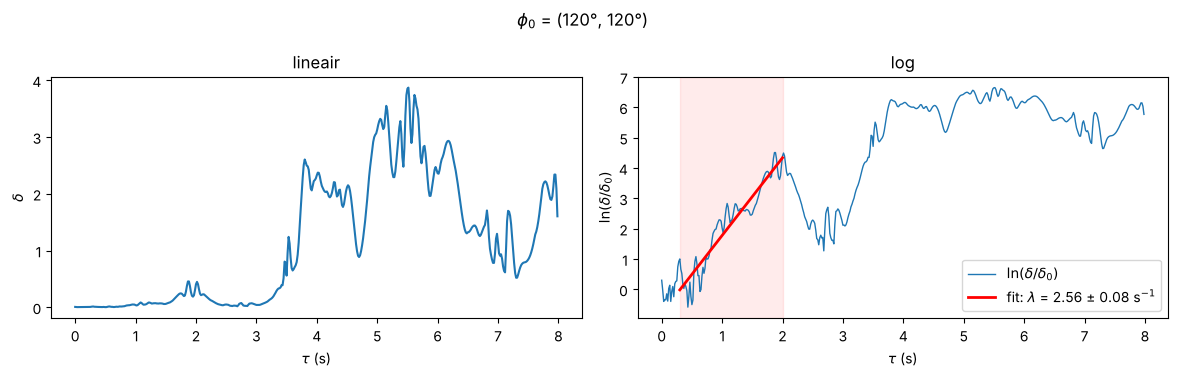

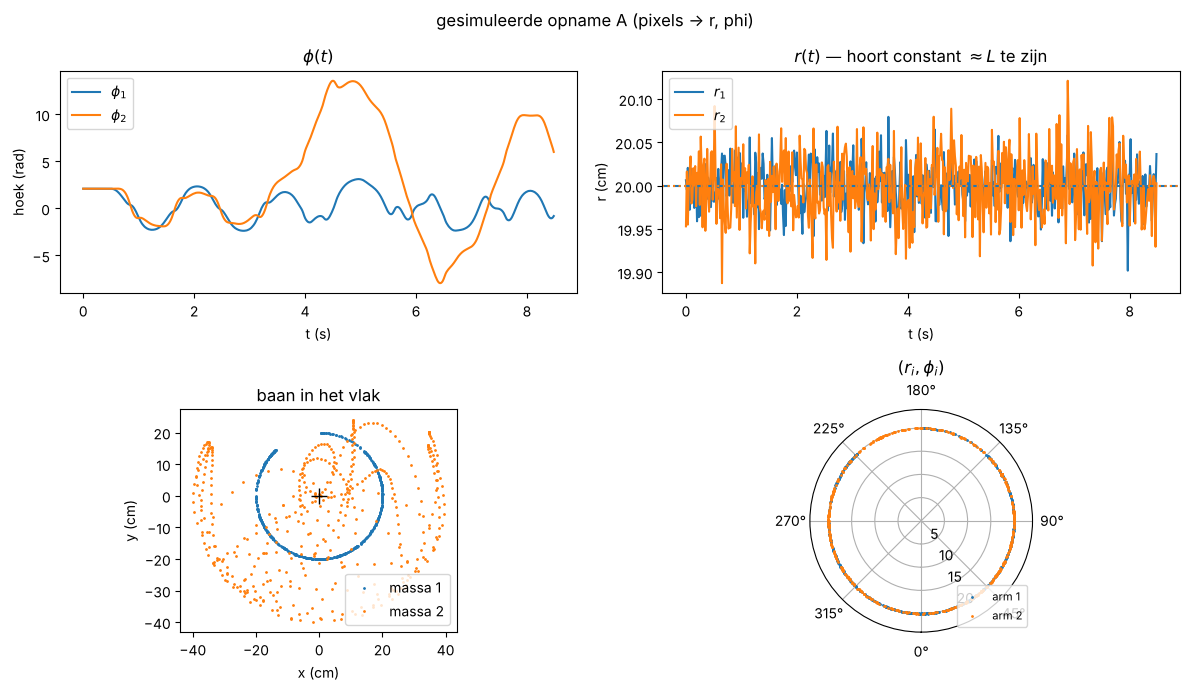

r1 = 20.00 ± 0.02 cm  (L1 = 20.0 cm)
r2 = 20.00 ± 0.04 cm  (L2 = 20.0 cm)


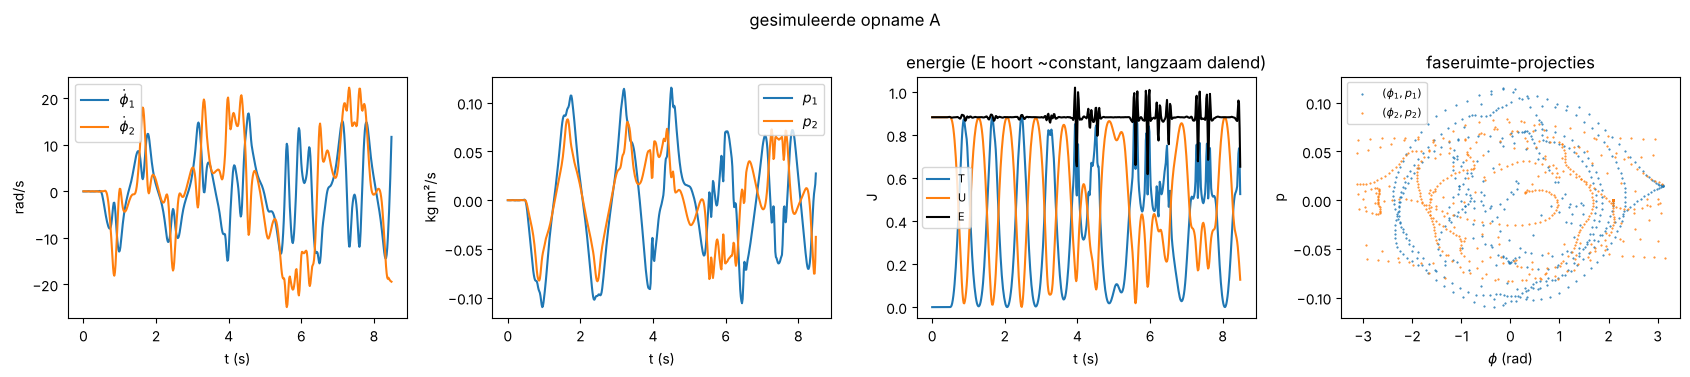

{'U0': np.float64(0.8835451394363274), 'lam': np.float64(2.561171441268081), 'lam_err': np.float64(0.08341424291642387), 'delta0': np.float64(0.005016373112240896)}


In [13]:
# Eén chaotisch paar, met alle tussenplots
res, (dfA, dfB) = run_pair(np.radians(120), np.radians(120), plot=True)
plot_polar(dfA, "gesimuleerde opname A (pixels -> r, phi)")
plot_canonical(dfA, "gesimuleerde opname A")
print(res)

sync: t0A = 0.533 s, t0B = 0.533 -> 0.5350 s


sync: t0A = 0.517 s, t0B = 0.517 -> 0.5175 s


sync: t0A = 0.517 s, t0B = 0.517 -> 0.5175 s


sync: t0A = 0.500 s, t0B = 0.517 -> 0.5000 s


sync: t0A = 0.500 s, t0B = 0.500 -> 0.5000 s


sync: t0A = 0.500 s, t0B = 0.517 -> 0.5000 s


sync: t0A = 0.517 s, t0B = 0.517 -> 0.5158 s


sync: t0A = 0.517 s, t0B = 0.517 -> 0.5158 s


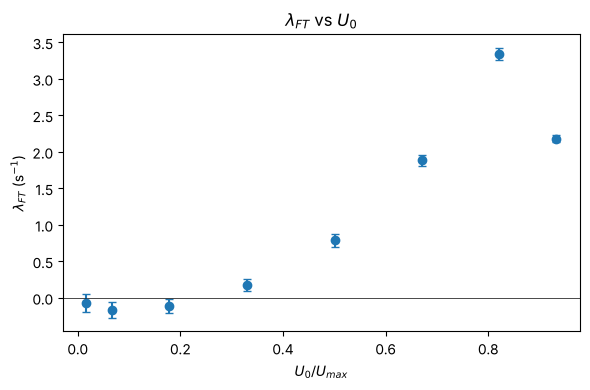

,U0,lam,lam_err,delta0
0,0.019947,-0.072338,0.125952,0.013041
1,0.078910,-0.165006,0.106571,0.004032
2,0.210350,-0.110010,0.094333,0.004514
3,0.388054,0.180075,0.081350,0.006595
4,0.589466,0.785960,0.092831,0.006425
5,0.790675,1.883896,0.071222,0.005424
6,0.967013,3.340647,0.082500,0.006153
7,1.098360,2.178204,0.047469,0.004444


In [14]:
# lambda_FT vs U0 voor een reeks beginhoeken (phi1_0 = phi2_0)
results = []
for ang in [15, 30, 50, 70, 90, 110, 130, 150]:
    r, _ = run_pair(np.radians(ang), np.radians(ang))
    results.append(r)
plot_lambda_vs_U0(results)